In [1]:
import rasterio as rio
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

In [2]:
mainPath = '/projectnb/modislc/users/sjstone/above/data/'
planet_path = '/projectnb/modislc/users/seamorez/HLS_FCover/PLSP/rawImage/PSScene/'

In [39]:
imgName = '20230714RNIR_20230806RNIR_PCA'

In [67]:
trainingDat = pd.read_csv(mainPath + 'trainingData/20230704_20230806_PCA_extract_v3.csv')
PCArast = rio.open(mainPath + 'pca/20230704RNIR_20230806RNIR_PCA.tif')
PCArastArray = PCArast.read()

In [68]:
# exported some training data with id column, so need to drop that
trainingDat = trainingDat.drop(columns = 'id')

In [69]:
# mask raster
planet = rio.open(planet_path + '20230806_200620_72_2440_3B_AnalyticMS_SR_8b_harmonized_clip.tif').read()
# planet = rio.open(planet_path + '20230920_204907_94_2473_3B_AnalyticMS_SR_8b_harmonized_clip.tif').read()

In [70]:
# bands = list(PCArast.descriptions)
bands = ['PC1', 'PC2', 'PC3', 'PC4']

In [71]:
imgFlat = []
for i in list(range(0, PCArastArray.shape[0])):
    layerFlat = list(PCArastArray[i, :, :].flatten())
    imgFlat.append(layerFlat)

In [72]:
PCA_df = pd.DataFrame(imgFlat).T

In [73]:
PCA_df.columns = bands

In [85]:
# PCA_df.to_csv(mainPath + 'planet_clip/20230704RGBNIR_20230819RGBNIR_0819clip.csv', index = False)

In [31]:
# PCA_df = PCA_df.T
# PCA_df.columns = [1, 2, 3, 4]

In [ ]:
# lstNAloc = TempSeasonalityRemoved.columns[pd.isna(TempSeasonalityRemoved).apply(sum) > 0].tolist()
# lstNAremoved = TempSeasonalityRemoved.drop(columns = lstNAloc + ['year', 'date'])

In [91]:
# NAloc = PCA_df.index[(PCA_df == 0).apply(sum, axis = 1) > 0]
# NAlocList = list(NAloc)
# PCA_df_NAdrop = PCA_df.drop(index = NAlocList)

In [74]:
train_x = trainingDat.iloc[:,1:PCArastArray.shape[0]+1]
train_x.columns = bands
train_y = trainingDat.iloc[:,0]

In [75]:
rf = RandomForestClassifier()
rf.fit(train_x, train_y)
y_pred = rf.predict(PCA_df)

In [108]:
# naList = pd.Series([np.nan] * len(NAlocList), index = NAlocList)
# predicted_full = pd.Series(y_pred, index = PCA_df_NAdrop.index).combine(naList, max).sort_index()

In [76]:
predArray = np.array(y_pred).reshape(1, PCArastArray.shape[1], PCArastArray.shape[2])

In [77]:
# masking out the locations where there is no planet data (plan has a value of 0) and assigning a value of 0
predArray[:, planet[0,:,:] == 0] = 0

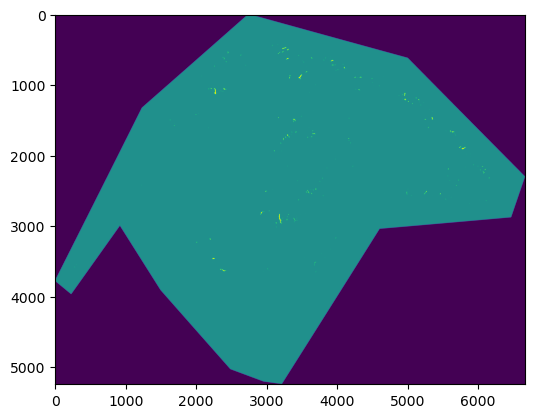

In [78]:
plt.imshow(predArray[0,:,:])

In [24]:
predArray.shape

(1, 5245, 6317)

In [79]:
rio.open(
#         mainPath + 'classification/' + imgName + '_classification_V1.tif',
        mainPath + 'classification/20230714RNIR_20230806RNIR_PCA_classification_V3.tif',
        'w',
        height=predArray.shape[1],
        width=predArray.shape[2],
        count=predArray.shape[0],
        dtype=rio.uint8,
        crs=PCArast.crs,
        transform=PCArast.transform,
        compress='lzw'
    ).write(predArray)

In [57]:
singleImg = rio.open(planet_path + '20230819_200348_13_2465_3B_AnalyticMS_SR_8b_harmonized_clip.tif') # get the necessary information from this read in (adjusted this to be the smaller area image)


julyImg = rio.open(mainPath + 'planet_clip/20230704_204446_10_2461_3B_AnalyticMS_SR_8b_harmonized_clip_0819clip.tif').read([2, 4, 6, 8])
aug19Img = rio.open(planet_path + '20230819_200348_13_2465_3B_AnalyticMS_SR_8b_harmonized_clip.tif').read([2, 4, 6, 8])

# masking
julyImg[:,aug19Img[0,:,:] == 0] = 0
# aug6Img[:,aug19Img[0,:,:] == 0] = 0
aug19Img[:,aug19Img[0,:,:] == 0] = 0
# slope[:,aug19Img[0,:,:] == 0] = 0
# slope[:,slope[0,:,:] == -9999] = 0
# elevation[:,aug19Img[0,:,:] == 0] = 0
# elevation[:,elevation[0,:,:] == -9999] = 0


# julyImg[:,septImg[0,:,:] == 0] = 0
# septImg[:,septImg[0,:,:] == 0] = 0

# singleImgRead = np.stack([NDVIjuly, NDVIaug19])
singleImgRead = np.concatenate([julyImg, aug19Img])

In [61]:
rio.open(
        mainPath + 'planet_clip/' + '20230704RGBNIR_20230819RGBNIR' + '_0819clip.tif',
        'w',
        height=singleImgRead.shape[1],
        width=singleImgRead.shape[2],
        count=singleImgRead.shape[0],
        dtype=rio.uint16,
        crs=singleImg.crs,
        transform=singleImg.transform,
        compress='lzw'
    ).write(singleImgRead)

In [59]:
singleImgRead.dtype.name

'uint16'

In [62]:
with rio.open(
    mainPath + 'planet_clip/' + '20230704RGBNIR_20230819RGBNIR' + '_0819clip.tif',
    'w',
#     driver='GTiff',
    height=singleImgRead.shape[1],
    width=singleImgRead.shape[2],
    count=singleImgRead.shape[0],
    dtype=rio.uint16,
    crs=singleImg.crs,
    transform=singleImg.transform,
    compress='lzw'
 ) as dst:
    dst.descriptions = ['20230704_R', '20230704_G', '20230704_B', '20230704_NIR',
                       '20230819_R', '20230819_G', '20230819_B', '20230819_NIR']
    dst.write(singleImgRead)
#     dst.descriptions()